In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns

In [3]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [11]:
df[['OSF','TWF','HDF','PWF','RNF']].value_counts()

OSF  TWF  HDF  PWF  RNF
0    0    0    0    0      9652
          1    0    0       106
          0    1    0        80
1    0    0    0    0        78
0    1    0    0    0        42
     0    0    0    1        18
1    0    0    1    0        11
          1    0    0         6
0    0    1    1    0         3
1    1    0    0    0         2
0    1    0    0    1         1
1    1    0    1    0         1
Name: count, dtype: int64

In [13]:
df.drop(columns=['OSF','TWF','HDF','PWF','RNF','UDI','Product ID'],axis=1,inplace=True)

In [15]:
df= pd.get_dummies(df,columns=['Type'],drop_first=True)

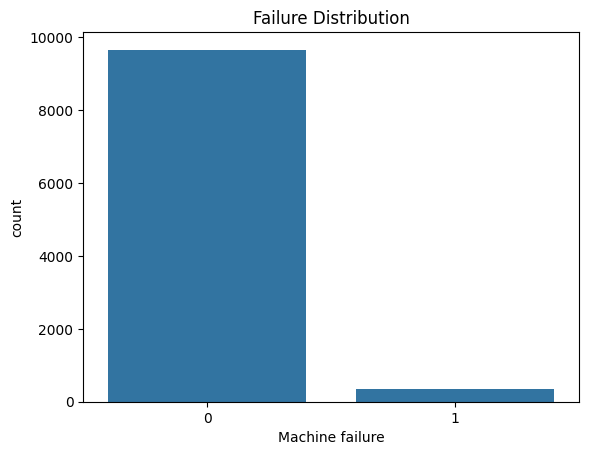

In [18]:
sns.countplot(x='Machine failure',data=df)
plt.title('Failure Distribution')
plt.show()

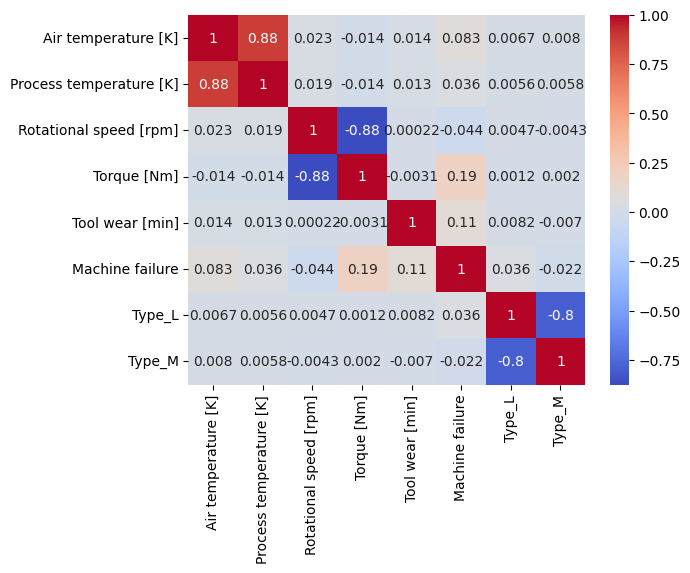

In [22]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [23]:
df

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False
...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0,False,True
9996,298.9,308.4,1632,31.8,17,0,False,False
9997,299.0,308.6,1645,33.4,22,0,False,True
9998,299.0,308.7,1408,48.5,25,0,False,False


In [24]:
features = ['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']

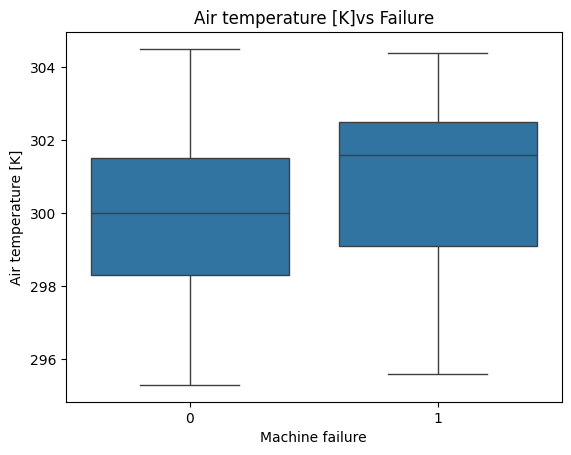

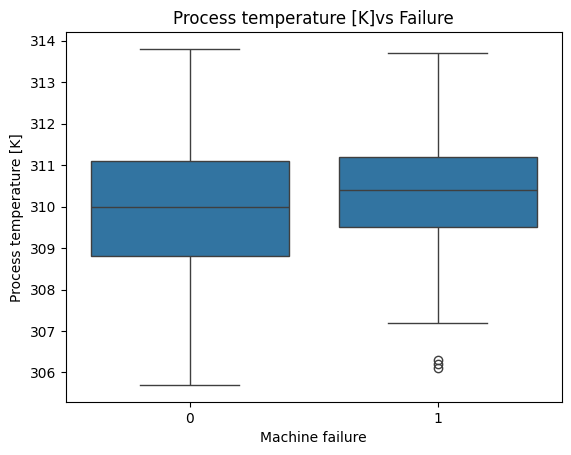

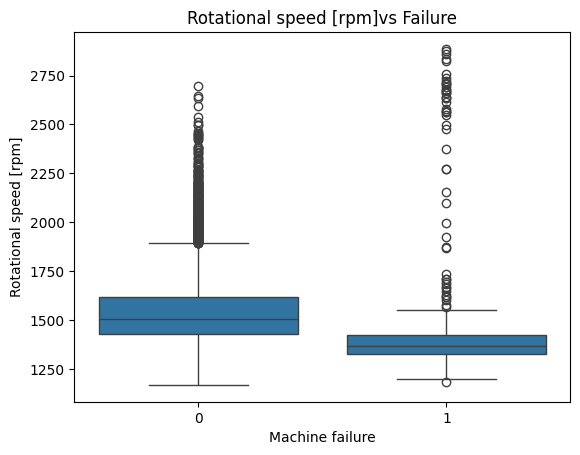

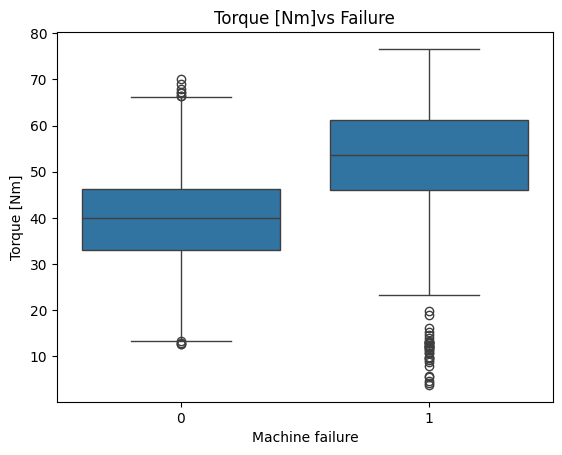

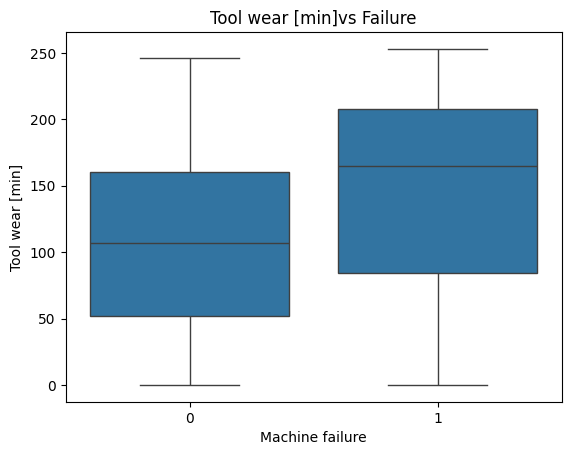

In [27]:
for feature in features:
    sns.boxplot(x='Machine failure',y=feature,data=df)
    plt.title(f"{feature}vs Failure")
    plt.show()

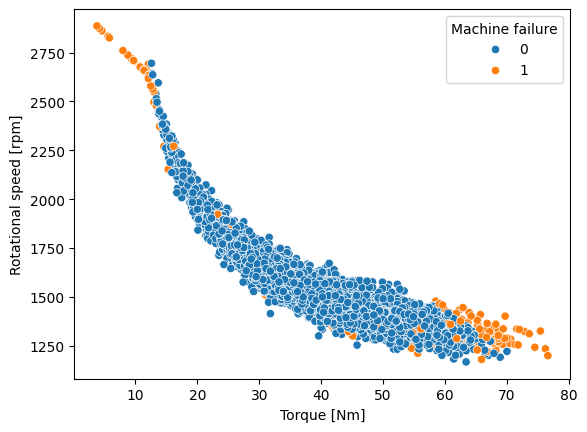

In [29]:
sns.scatterplot(x='Torque [Nm]',y='Rotational speed [rpm]',hue='Machine failure',data=df)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

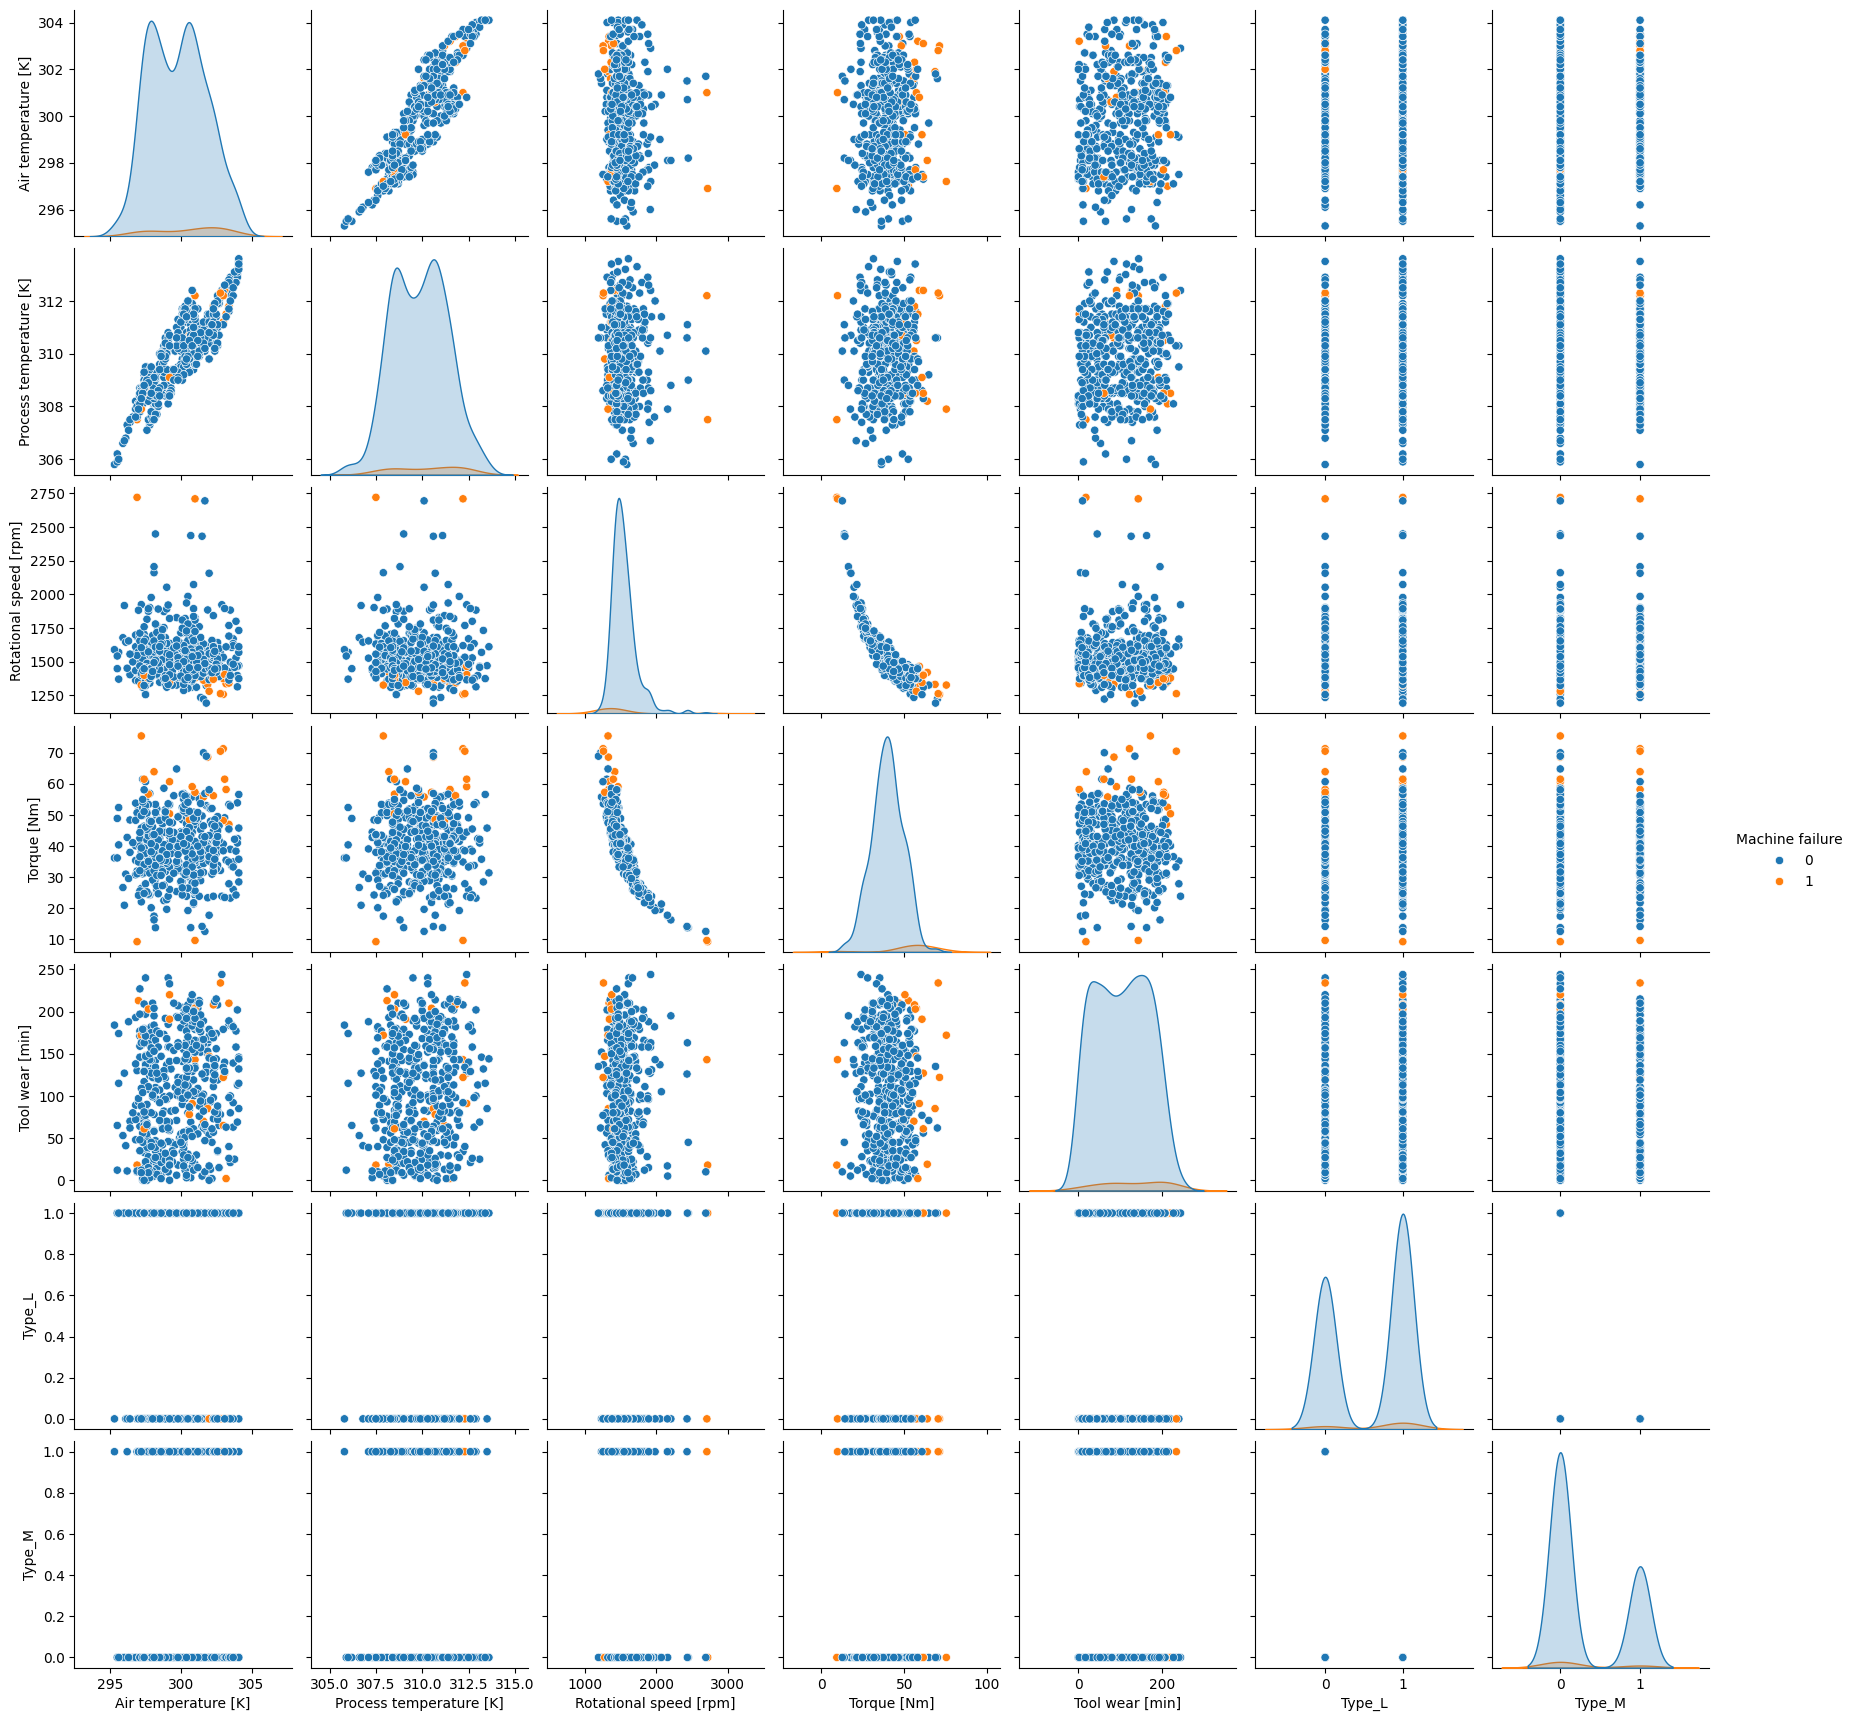

In [31]:
sns.pairplot(df.sample(500),hue='Machine failure')
plt.show

In [32]:
x = df.drop('Machine failure',axis=1)
y = df['Machine failure']

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [36]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [41]:
y_pred=model.predict(x_test)

In [44]:
print('Accuracy:',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9825
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.84      0.52      0.65        61

    accuracy                           0.98      2000
   macro avg       0.91      0.76      0.82      2000
weighted avg       0.98      0.98      0.98      2000



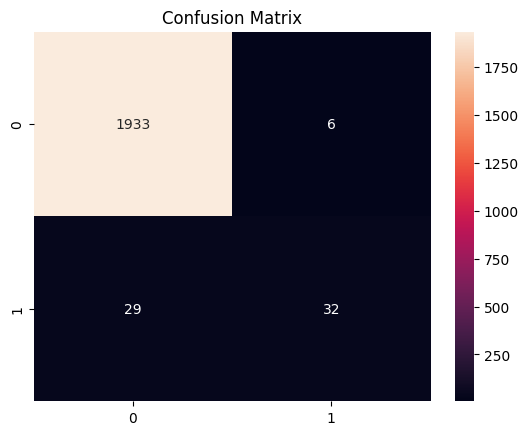

In [49]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [50]:
import pickle
pickle.dump(model,open('model.pkl','wb'))

### Create app.py

In [60]:
import streamlit as st 
import pickle 
import numpy as np 

model = pickle.load(open('model.pkl','rb'))

st.title("predictive Maintenance System")

air_temp = st.number_input("Air Temperature")
process_temp = st.number_input("process Temperature")
rot_speed = st.number_input("Rotational Speed")
torque = st.number_input("Torque")
tool_wear = st.number_input("Tool Wear")

type_L = st.selectbox("Type L",[0,1])
type_M = st.selectbox("Type M",[0,1])

if st.button("predict"): 
    input_data = np.array([[air_temp,process_temp,rot_speed,torque,tool_wear,type_L,type_M]])
    prediction = model.predict(input_data)
    if prediction[0] == 1: 
               st.error("Machine Failure Likely")
    else:
               st.success("Machine is Safe")

2026-05-03 16:01:50.641 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 16:01:51.241 
  command:

    streamlit run C:\Users\shahn\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-03 16:01:51.243 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 16:01:51.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 16:01:51.246 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 16:01:51.247 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 16:01:51.248 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 16:01:51.251 Thread 'MainThread': missing ScriptRunContext! This warnin